# NLP Sentiment Beliefs for Black-Litterman Portfolio Optimization

This notebook implements the NLP component of our Bayesian Black-Litterman portfolio optimization system.

## Pipeline Overview
1. **Install & Import**: dependencies and configuration
2. **Load Labeled Data**: Twitter Financial News Sentiment (HuggingFace) for fine-tuning
3. **Fine-tune FinBERT**: adapt to tweet-domain financial language
4. **Evaluate Fine-tuned Model**: accuracy, F1, comparison to base FinBERT
5. **Load Inference Data**: Kaggle Stock Tweets 2021–2022
6. **Run Inference**: score every tweet with the fine-tuned model
7. **Aggregate by Ticker × Period**: mean sentiment, std, mention volume
8. **Generate Absolute Beliefs**: absolute beliefs
9. **Generate Relative Beliefs**: relative beliefs (BL views)

## Output Schema
- `nlp_absolute_beliefs_df` — columns: Ticker, ExpectedReturn, ProbabilityPositive, Confidence
- `nlp_relative_beliefs_df` — columns: Asset_A, Asset_B, MeanRelativeReturn, StdRelativeReturn, ProbabilityOutperform

---
## 1. Install Dependencies

In [ ]:
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers[torch]",   # installs compatible torch + accelerate
    "datasets",
    "scikit-learn",
    "kaggle",
    "--upgrade",
])

# Restart runtime now before running imports

---
## 2. Imports & Configuration

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import combinations

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURATION
# ============================================================

TICKERS = ["AAPL", "MSFT", "TSLA", "TSM", "PG"]

# Ticker
TICKER_ALIASES = {
    "AAPL": ["$AAPL", "AAPL", "Apple"],
    "MSFT": ["$MSFT", "MSFT", "Microsoft"],
    "TSLA": ["$TSLA", "TSLA", "Tesla"],
    "TSM":  ["$TSM", "TSMC", "Taiwan Semiconductor"],  # bare "TSM" matches too noisy
    "PG":   ["$PG", "Procter & Gamble", "Procter and Gamble"],  # bare "PG" matches too noisy
}

BASE_MODEL        = "ProsusAI/finbert"       # pretrained FinBERT checkpoint
FINETUNED_DIR     = "./finbert_finetuned"    # where fine-tuned weights are saved
MAX_LEN           = 128                      # token limit for tweets
BATCH_SIZE        = 16
NUM_EPOCHS        = 3
LEARNING_RATE     = 2e-5
RANDOM_SEED       = 42

# Sentiment aggregation
AGG_PERIOD        = "M"    # 'M' = monthly
MIN_MENTIONS      = 5      # min tweets per ticker-period to include

# Relative view threshold: only generate a view if |sentiment diff| > threshold
VIEW_THRESHOLD    = 0.005

# FinBERT label mapping
# ProsusAI/finbert: 0=positive, 1=negative, 2=neutral
FINBERT_ID2LABEL  = {0: "positive", 1: "negative", 2: "neutral"}
FINBERT_LABEL2ID  = {v: k for k, v in FINBERT_ID2LABEL.items()}

# Twitter Financial News Sentiment label mapping
# zeroshot dataset: 0=Bearish, 1=Bullish, 2=Neutral --> map to FinBERT ids
TFNS_REMAP        = {0: 1, 1: 0, 2: 2}  # Bearish = negative(1), Bullish = positive(0), Neutral = neutral(2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Tickers: {TICKERS}")
print(f"Base model: {BASE_MODEL}")

Device: cuda
Tickers: ['AAPL', 'MSFT', 'TSLA', 'TSM', 'PG']
Base model: ProsusAI/finbert


---
## 3. Load Fine-tuning Dataset

We use the **Twitter Financial News Sentiment** dataset from HuggingFace (`zeroshot/twitter-financial-news-sentiment`).
- 11,932 finance tweets labeled Bearish / Bullish / Neutral
- Same domain (financial tweets) as our Kaggle inference data

Labels are remapped to match FinBERT's convention: Bullish --> positive, Bearish --> negative, Neutral --> neutral.

In [ ]:
print("Loading Twitter Financial News Sentiment dataset...")

# Verify library versions (debugging compatibility issues)
import transformers, accelerate, datasets as ds_lib
print(f"transformers : {transformers.__version__}")
print(f"accelerate   : {accelerate.__version__}")
print(f"datasets     : {ds_lib.__version__}")
print()

tfns = load_dataset("zeroshot/twitter-financial-news-sentiment")

train_raw = tfns["train"]
val_raw   = tfns["validation"]

print(f"Train size : {len(train_raw):,}")
print(f"Val size   : {len(val_raw):,}")
print()
print("Sample record:")
print(train_raw[0])
print()

# Label distribution
label_names  = ["Bearish", "Bullish", "Neutral"]
train_labels = [TFNS_REMAP[x] for x in train_raw["label"]]
val_labels   = [TFNS_REMAP[x] for x in val_raw["label"]]

train_counts = pd.Series(train_labels).value_counts().sort_index()
print("Remapped train label distribution (0=pos, 1=neg, 2=neutral):")
print(train_counts.to_string())

Loading Twitter Financial News Sentiment dataset...
transformers : 5.0.0
accelerate   : 1.13.0
datasets     : 4.0.0



README.md: 0.00B [00:00, ?B/s]

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

Train size : 9,543
Val size   : 2,388

Sample record:
{'text': '$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT', 'label': 0}

Remapped train label distribution (0=pos, 1=neg, 2=neutral):
0    1923
1    1442
2    6178


---
## 4. Tokenize & Build PyTorch Datasets (Train/Val/Test)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


class TweetDataset(Dataset):
    """
    Wraps a HuggingFace dataset split for fine-tuning.
    Remaps TFNS labels to FinBERT label space on the fly.
    """

    def __init__(self, hf_split, tokenizer, max_len=MAX_LEN):
        self.texts  = hf_split["text"]
        self.labels = [TFNS_REMAP[x] for x in hf_split["label"]]
        self.tok    = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = TweetDataset(train_raw, tokenizer)
val_dataset   = TweetDataset(val_raw,   tokenizer)

print(f"Train dataset: {len(train_dataset):,} samples")
print(f"Val dataset  : {len(val_dataset):,} samples")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Train dataset: 9,543 samples
Val dataset  : 2,388 samples


In [ ]:
from torch.utils.data import random_split

# Split the HF validation set: 50% for trainer eval, 50% for final held-out test
# Use a fixed seed for reproducibility
val_hf_size  = len(val_raw)
eval_size    = val_hf_size // 2
test_size    = val_hf_size - eval_size

full_val_dataset = TweetDataset(val_raw, tokenizer)

eval_dataset, test_dataset = random_split(
    full_val_dataset,
    [eval_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

print(f"Trainer eval size : {eval_size}")
print(f"Held-out test size: {test_size}")

Trainer eval size : 1194
Held-out test size: 1194


---
## 5. Fine-tune FinBERT

We load `ProsusAI/finbert` and fine-tune its classification head on the financial tweet-domain labeled data.

In [ ]:
from transformers import DataCollatorWithPadding

def compute_metrics(eval_pred):
    """Metrics function passed to HuggingFace Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }


print("Loading base FinBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    id2label=FINBERT_ID2LABEL,
    label2id=FINBERT_LABEL2ID,
    ignore_mismatched_sizes=True,
)
model.to(device)

training_args = TrainingArguments(
    output_dir=FINETUNED_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    seed=RANDOM_SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning...")
train_result = trainer.train()

print("\nFine-tuning complete.")
print(f"  Train loss : {train_result.training_loss:.4f}")
print(f"  Train steps: {train_result.global_step}")

trainer.save_model(FINETUNED_DIR)
tokenizer.save_pretrained(FINETUNED_DIR)
print(f"\nModel saved to: {FINETUNED_DIR}")

Loading base FinBERT model...


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting fine-tuning...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Fine-tuning complete.
  Train loss : 0.2640
  Train steps: 1791


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: ./finbert_finetuned


---
## 6. Evaluate: Fine-tuned vs. Base FinBERT

We compare both models on the test set.
Metrics: per-class F1, macro-F1, accuracy, and confusion matrix.

In [ ]:
def predict_dataset(model, dataset, batch_size=BATCH_SIZE):
    """
    Run inference on a TweetDataset and return
    (true_labels, predicted_labels).
    """
    model.eval()
    all_preds  = []
    all_labels = []

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=-1).cpu()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    return all_labels, all_preds


# ── Fine-tuned model evaluation ──────────────────────────────
print("Evaluating fine-tuned FinBERT on test set...")
ft_true, ft_preds = predict_dataset(model, test_dataset)

ft_acc = accuracy_score(ft_true, ft_preds)
ft_f1  = f1_score(ft_true, ft_preds, average="macro")

print("\n── Fine-tuned FinBERT ──")
print(f"  Accuracy : {ft_acc:.4f}")
print(f"  Macro F1 : {ft_f1:.4f}")
print()
print(classification_report(
    ft_true, ft_preds,
    target_names=["positive", "negative", "neutral"]
))

# ── Base FinBERT evaluation (no fine-tuning) ─────────────────
print("Evaluating BASE FinBERT on test set...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    ignore_mismatched_sizes=True,
).to(device)

base_true, base_preds = predict_dataset(base_model, test_dataset)

base_acc = accuracy_score(base_true, base_preds)
base_f1  = f1_score(base_true, base_preds, average="macro")

print("\n── Base FinBERT (no fine-tuning) ──")
print(f"  Accuracy : {base_acc:.4f}")
print(f"  Macro F1 : {base_f1:.4f}")
print()
print(classification_report(
    base_true, base_preds,
    target_names=["positive", "negative", "neutral"]
))

# Free base model from GPU
del base_model
torch.cuda.empty_cache()

Evaluating fine-tuned FinBERT on test set...

── Fine-tuned FinBERT ──
  Accuracy : 0.8786
  Macro F1 : 0.8395

              precision    recall  f1-score   support

    positive       0.82      0.82      0.82       231
    negative       0.74      0.83      0.78       166
     neutral       0.93      0.91      0.92       797

    accuracy                           0.88      1194
   macro avg       0.83      0.85      0.84      1194
weighted avg       0.88      0.88      0.88      1194

Evaluating BASE FinBERT on test set...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── Base FinBERT (no fine-tuning) ──
  Accuracy : 0.7303
  Macro F1 : 0.6690

              precision    recall  f1-score   support

    positive       0.62      0.62      0.62       231
    negative       0.48      0.75      0.58       166
     neutral       0.86      0.76      0.81       797

    accuracy                           0.73      1194
   macro avg       0.65      0.71      0.67      1194
weighted avg       0.76      0.73      0.74      1194



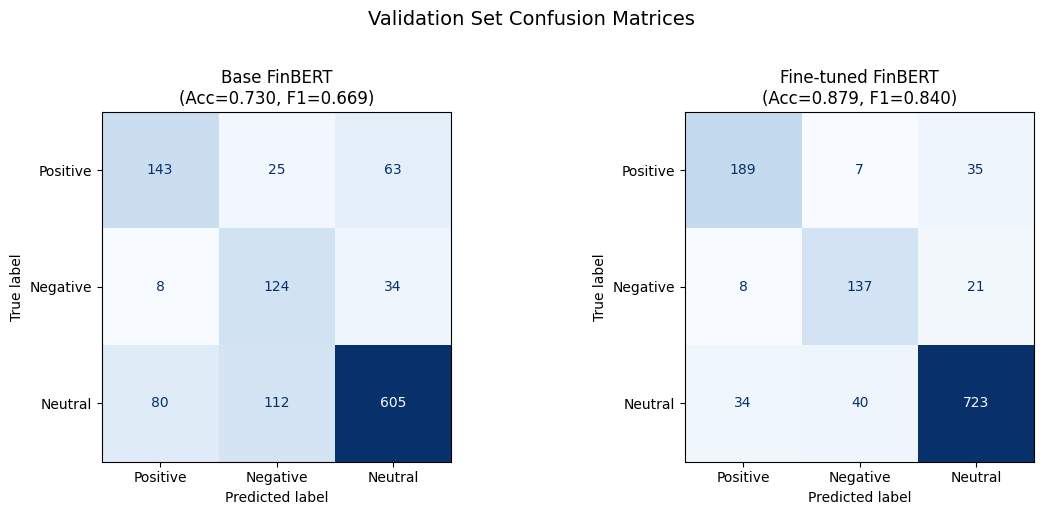


Model Comparison Summary


,Model,Accuracy,Macro F1,Delta Acc,Delta F1
0,Base FinBERT,0.730318,0.669016,,
1,Fine-tuned FinBERT,0.878559,0.839517,++0.1482,++0.1705


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

label_names_display = ["Positive", "Negative", "Neutral"]

for ax, true, preds, title in [
    (axes[0], base_true,  base_preds, f"Base FinBERT\n(Acc={base_acc:.3f}, F1={base_f1:.3f})"),
    (axes[1], ft_true,    ft_preds,   f"Fine-tuned FinBERT\n(Acc={ft_acc:.3f}, F1={ft_f1:.3f})"),
]:
    cm = confusion_matrix(true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names_display)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12)

plt.suptitle("Validation Set Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary comparison
comparison = pd.DataFrame({
    "Model":    ["Base FinBERT", "Fine-tuned FinBERT"],
    "Accuracy": [base_acc, ft_acc],
    "Macro F1": [base_f1,  ft_f1],
    "Delta Acc": ["", f"+{ft_acc - base_acc:+.4f}"],
    "Delta F1":  ["", f"+{ft_f1 - base_f1:+.4f}"],
})

print("\nModel Comparison Summary")
display(comparison)

---
## 7. Load Kaggle Inference Data

Downloaded CSV from Kaggle:

https://www.kaggle.com/datasets/equinxx/stock-tweets-for-sentiment-analysis-and-prediction

In [ ]:
# load csv
KAGGLE_CSV = "stock_tweets.csv"

tweets_raw = pd.read_csv(KAGGLE_CSV, encoding="utf-8", on_bad_lines="skip")

print(f"Raw shape: {tweets_raw.shape}")
print(f"Columns  : {tweets_raw.columns.tolist()}")
display(tweets_raw.head(3))

Raw shape: (80793, 4)
Columns  : ['Date', 'Tweet', 'Stock Name', 'Company Name']


,Date,Tweet,Stock Name,Company Name
0,2022-09-29 23:41:16+00:00,Mainstream media has done an amazing job at br...,TSLA,"Tesla, Inc."
1,2022-09-29 23:24:43+00:00,Tesla delivery estimates are at around 364k fr...,TSLA,"Tesla, Inc."
2,2022-09-29 23:18:08+00:00,3/ Even if I include 63.0M unvested RSUs as of...,TSLA,"Tesla, Inc."


---
## 8. Preprocess & Filter Tweets by Ticker

In [ ]:
import re

def assign_ticker(text, aliases=TICKER_ALIASES):
    found = []
    text_str = str(text)
    for ticker, alias_list in aliases.items():
        for alias in alias_list:
            if alias.startswith("$"):
                # cashtag: match literally, case-insensitive
                if alias.upper() in text_str.upper():
                    found.append(ticker)
                    break
            else:
                # company name / bare ticker: require word boundaries
                if re.search(rf"\b{re.escape(alias)}\b", text_str, re.IGNORECASE):
                    found.append(ticker)
                    break
    return found


# Detect the text column name (common variants)
text_col = next(
    (c for c in tweets_raw.columns if c.lower() in ["tweet", "text", "body", "content"]),
    tweets_raw.columns[0]
)
date_col = next(
    (c for c in tweets_raw.columns if "date" in c.lower() or "time" in c.lower()),
    None
)

print(f"Using text column : '{text_col}'")
print(f"Using date column : '{date_col}'")

tweets = tweets_raw[[text_col] + ([date_col] if date_col else [])].copy()
tweets.columns = ["text"] + (["date"] if date_col else [])

if date_col:
    tweets["date"] = pd.to_datetime(tweets["date"], utc=True, errors="coerce")
    tweets["date"] = tweets["date"].dt.tz_localize(None)
    tweets = tweets.dropna(subset=["date"])

# Drop empty / too-short tweets
tweets = tweets.dropna(subset=["text"])
tweets = tweets[tweets["text"].str.len() > 10].reset_index(drop=True)

# Assign tickers + explode so each row = one tweet × one ticker
tweets["tickers"] = tweets["text"].apply(assign_ticker)
tweets = tweets[tweets["tickers"].map(len) > 0]  # drop unmatched tweets
tweets = tweets.explode("tickers").rename(columns={"tickers": "ticker"})
tweets = tweets[tweets["ticker"].isin(TICKERS)].reset_index(drop=True)

print(f"\nFiltered tweets (ticker-matched): {len(tweets):,}")
print("\nMentions per ticker:")
print(tweets["ticker"].value_counts().to_string())

Using text column : 'Tweet'
Using date column : 'Date'

Filtered tweets (ticker-matched): 63,423

Mentions per ticker:
ticker
TSLA    44211
AAPL    12107
MSFT     5987
TSM       601
PG        517


---
## 9. Run Inference with Fine-tuned FinBERT

Each tweet is scored as a sentiment scalar:

```
score = P(positive) - P(negative)  ∈ [-1, +1]
```

We use batched inference for efficiency.

In [ ]:
from torch.nn.functional import softmax


def batch_sentiment_scores(
    texts,
    model,
    tokenizer,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
):
    """
    Return a numpy array of sentiment scores in [-1, +1].
    score = P(positive) - P(negative)

    Label convention (FinBERT / our fine-tuned model):
        0 = positive, 1 = negative, 2 = neutral
    """
    model.eval()
    scores = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]

        enc = tokenizer(
            batch,
            max_length=max_len,
            padding=True,
            truncation=True,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            logits = model(**enc).logits          # (batch, 3)
            probs  = softmax(logits, dim=-1).cpu().numpy()

        # score = P(positive)[col 0] - P(negative)[col 1]
        batch_scores = probs[:, 0] - probs[:, 1]
        scores.extend(batch_scores.tolist())

        if (start // batch_size) % 50 == 0:
            pct = min(100, 100 * (start + batch_size) / len(texts))
            print(f"  Inference progress: {pct:.0f}%", end="\r")

    print("  Inference progress: 100%  ")
    return np.array(scores)


print(f"Running inference on {len(tweets):,} tweet-ticker rows...")
tweets["sentiment_score"] = batch_sentiment_scores(
    tweets["text"].tolist(),
    model,
    tokenizer,
)

print("\nSentiment score distribution:")
print(tweets["sentiment_score"].describe().round(4).to_string())

Running inference on 63,423 tweet-ticker rows...
  Inference progress: 100%  

Sentiment score distribution:
count    63423.0000
mean         0.0893
std          0.4686
min         -0.9924
25%         -0.0007
50%          0.0005
75%          0.0471
max          0.9957


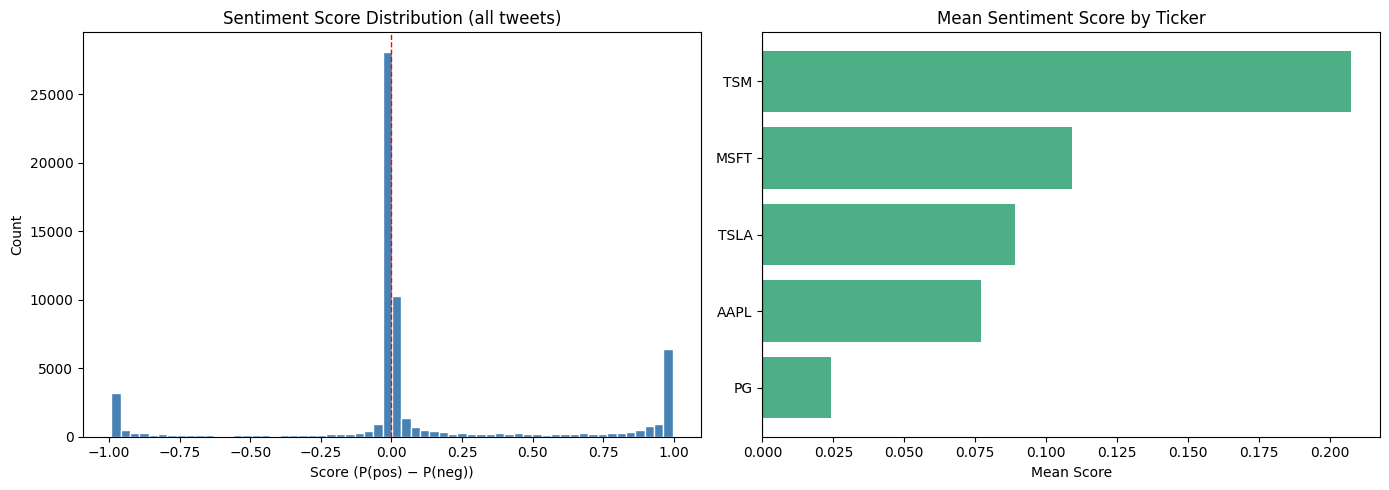

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of raw scores
axes[0].hist(tweets["sentiment_score"], bins=60, edgecolor="white", color="steelblue")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Sentiment Score Distribution (all tweets)")
axes[0].set_xlabel("Score (P(pos) − P(neg))")
axes[0].set_ylabel("Count")

# Mean score per ticker
ticker_means = tweets.groupby("ticker")["sentiment_score"].mean().sort_values()
colors = ["#e05555" if v < 0 else "#4caf85" for v in ticker_means]
axes[1].barh(ticker_means.index, ticker_means.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Mean Sentiment Score by Ticker")
axes[1].set_xlabel("Mean Score")

plt.tight_layout()
plt.show()

---
## 10. Aggregate Sentiment by Ticker × Period

We group by ticker and calendar period (`AGG_PERIOD`, default monthly).

For each bucket we compute:
- `mean_sentiment` — volume-weighted mean score
- `sentiment_std` — standard deviation (→ uncertainty / Omega)
- `n_mentions` — number of tweets (low volume = higher uncertainty)

In [ ]:
if "date" in tweets.columns:
    tweets["period"] = tweets["date"].dt.to_period(AGG_PERIOD)
    group_cols = ["ticker", "period"]
else:
    # No date column: treat entire dataset as one period
    tweets["period"] = "all"
    group_cols = ["ticker", "period"]

agg = (
    tweets
    .groupby(group_cols)["sentiment_score"]
    .agg(
        mean_sentiment="mean",
        sentiment_std="std",
        n_mentions="count",
    )
    .reset_index()
)

# Fill NaN std (single-tweet periods) with a high-uncertainty value
agg["sentiment_std"] = agg["sentiment_std"].fillna(1.0)

# Apply minimum mention filter
agg = agg[agg["n_mentions"] >= MIN_MENTIONS].reset_index(drop=True)

print(f"Aggregation period  : {AGG_PERIOD}")
print(f"Buckets after filter: {len(agg)}")
print()
display(agg.head(10))

Aggregation period  : M
Buckets after filter: 62



,ticker,period,mean_sentiment,sentiment_std,n_mentions
0,AAPL,2021-09,0.494057,0.532216,13
1,AAPL,2021-10,0.073732,0.437052,1027
2,AAPL,2021-11,0.154820,0.468612,967
3,AAPL,2021-12,0.185695,0.484617,1077
4,AAPL,2022-01,0.109202,0.472010,1069
5,AAPL,2022-02,0.050670,0.485258,810
6,AAPL,2022-03,0.114900,0.450181,894
7,AAPL,2022-04,0.015195,0.533403,1423
8,AAPL,2022-05,-0.013720,0.563442,1092
9,AAPL,2022-06,-0.010937,0.450570,669


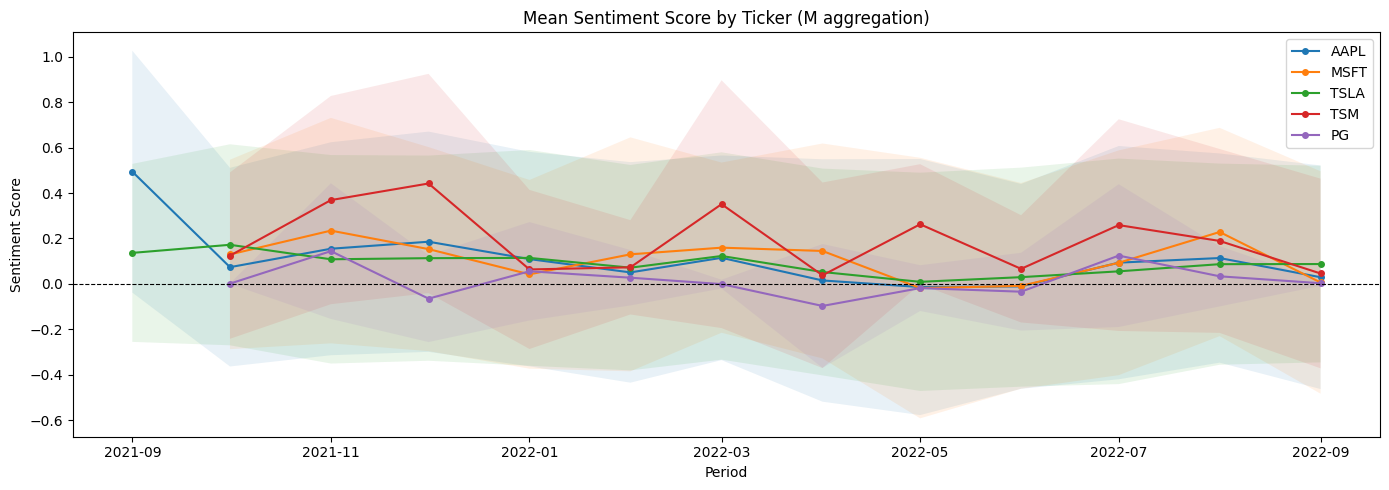

In [ ]:
if "date" in tweets.columns:
    fig, ax = plt.subplots(figsize=(14, 5))

    for ticker in TICKERS:
        sub = agg[agg["ticker"] == ticker].copy()
        if sub.empty:
            continue
        sub["period_dt"] = sub["period"].dt.to_timestamp()
        ax.plot(
            sub["period_dt"],
            sub["mean_sentiment"],
            marker="o",
            markersize=4,
            label=ticker,
        )
        ax.fill_between(
            sub["period_dt"],
            sub["mean_sentiment"] - sub["sentiment_std"],
            sub["mean_sentiment"] + sub["sentiment_std"],
            alpha=0.1,
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Mean Sentiment Score by Ticker ({AGG_PERIOD} aggregation)")
    ax.set_xlabel("Period")
    ax.set_ylabel("Sentiment Score")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 11. Generate Absolute NLP Beliefs

We collapse the time-series aggregation into a single set of beliefs over the full dataset window.

**ProbabilityPositive:** Volume-weighted soft probability of positive returns.

- Instead of counting positive periods, compute a continuous probability that accounts for both the direction and strength of sentiment in each period, weighted by mention volume

- Strong positive sentiment contributes more than weak positive sentiment, and high-traffic periods receive greater weight.

**Confidence:** Directional conviction derived from the distance of ProbabilityPositive from neutrality

- Higher values indicate stronger consensus toward bullish or bearish sentiment, while values near zero indicate uncertainty or mixed signals.

| Column | HMM source | NLP source |
|---|---|---|
| `Ticker` | ticker | ticker |
| `ExpectedReturn` | MC mean total return | sentiment score scaled to return units |
| `ProbabilityPositive` | P(sim return > 0) | volume-weighted mean of sigmoid(sentiment × temperature) |
| `Confidence` | 2·\|P−0.5\| | 2·\|P−0.5\| |

> **Scaling note:** Sentiment scores are dimensionless in [−1, +1]. We scale them to rough return units using a calibration factor `SENTIMENT_RETURN_SCALE` (default 0.15 = ±15% annual). Adjust based on backtesting calibration.

In [ ]:
from scipy.special import expit  # sigmoid function

# Scaling factor: maps [-1, +1] sentiment to expected annual return units
# e.g. 0.15 means a perfectly positive sentiment implies +15% expected return
SENTIMENT_RETURN_SCALE = 0.15

nlp_absolute_beliefs = []

for ticker in TICKERS:

    sub = agg[agg["ticker"] == ticker]

    if sub.empty:
        # If no data for this ticker, insert a neutral / zero-confidence row
        nlp_absolute_beliefs.append({
            "Ticker":              ticker,
            "ExpectedReturn":      0.0,
            "ProbabilityPositive": 0.5,
            "Confidence":          0.0,
        })
        continue

    # Overall mean sentiment across all periods
    # Weight by mention count so high-volume periods matter more
    weights        = sub["n_mentions"].values
    period_scores  = sub["mean_sentiment"].values

    overall_mean   = np.average(period_scores, weights=weights)
    overall_std    = np.sqrt(
        np.average((period_scores - overall_mean) ** 2, weights=weights)
    )

    ## P(positive): fraction of periods with positive sentiment

    # Scale sentiment scores to probabilities via sigmoid
    # Multiply by a temperature factor to control how quickly weak sentiment is penalized
    TEMPERATURE = 15
    period_probs = expit(period_scores * TEMPERATURE)  # maps [-1,1] to (0,1)

    # Weight by mention volume, so high-traffic periods matter more
    prob_positive = np.average(period_probs, weights=weights)

    # Confidence
    confidence = abs(prob_positive - 0.5) * 2

    # Expected return: scale sentiment to return units
    expected_return = overall_mean * SENTIMENT_RETURN_SCALE

    nlp_absolute_beliefs.append({
        "Ticker":              ticker,
        "ExpectedReturn":      expected_return,
        "ProbabilityPositive": prob_positive,
        "Confidence":          confidence,
        "SentimentMean":       overall_mean,
        "SentimentStd":        overall_std,
        "TotalMentions":       int(sub["n_mentions"].sum()),
    })


nlp_absolute_beliefs_df = pd.DataFrame(nlp_absolute_beliefs)

print("NLP Absolute Beliefs")
display(nlp_absolute_beliefs_df)

NLP Absolute Beliefs


,Ticker,ExpectedReturn,ProbabilityPositive,Confidence,SentimentMean,SentimentStd,TotalMentions
0,AAPL,0.011566,0.725483,0.450966,0.077107,0.062451,12107
1,MSFT,0.016346,0.782571,0.565141,0.108971,0.078197,5984
2,TSLA,0.013368,0.772339,0.544677,0.089122,0.044493,44211
3,TSM,0.031107,0.871070,0.742139,0.207382,0.139015,601
4,PG,0.003634,0.567773,0.135546,0.024225,0.078069,517


---
## 12. Generate Relative NLP Beliefs

For every pair (A, B) we compute:
- `MeanRelativeReturn` — scaled sentiment differential between A and B
- `StdRelativeReturn` — propagated uncertainty from both assets
- `ProbabilityOutperform` — P(sentiment_A > sentiment_B) across time periods

Only pairs where `|MeanRelativeReturn| > VIEW_THRESHOLD` become active Black-Litterman views.


In [ ]:
nlp_relative_beliefs = []

for asset_a, asset_b in combinations(TICKERS, 2):

    sub_a = agg[agg["ticker"] == asset_a]
    sub_b = agg[agg["ticker"] == asset_b]

    if sub_a.empty or sub_b.empty:
        continue

    # Align on shared periods
    merged = pd.merge(
        sub_a[["period", "mean_sentiment", "sentiment_std", "n_mentions"]],
        sub_b[["period", "mean_sentiment", "sentiment_std", "n_mentions"]],
        on="period",
        suffixes=("_a", "_b"),
    )

    if merged.empty:
        continue

    # Per-period relative sentiment
    relative_diff = merged["mean_sentiment_a"] - merged["mean_sentiment_b"]

    mean_diff          = relative_diff.mean()
    std_diff           = relative_diff.std() if len(relative_diff) > 1 else 1.0
    period_rel_probs = expit(relative_diff.values * TEMPERATURE)
    prob_outperform  = np.mean(period_rel_probs)

    # Scale to return units (same scale as absolute beliefs)
    mean_relative_return = mean_diff * SENTIMENT_RETURN_SCALE
    std_relative_return  = std_diff  * SENTIMENT_RETURN_SCALE

    nlp_relative_beliefs.append({
        "Asset_A":             asset_a,
        "Asset_B":             asset_b,
        "MeanRelativeReturn":  mean_relative_return,
        "StdRelativeReturn":   std_relative_return,
        "ProbabilityOutperform": prob_outperform,
        # Extra: raw sentiment diff and n shared periods
        "MeanSentimentDiff":   mean_diff,
        "SharedPeriods":       len(merged),
        "ActiveView":          abs(mean_relative_return) > VIEW_THRESHOLD,
    })


nlp_relative_beliefs_df = pd.DataFrame(nlp_relative_beliefs)

print("NLP Relative Beliefs (all pairs)")
display(nlp_relative_beliefs_df)

active_views = nlp_relative_beliefs_df[nlp_relative_beliefs_df["ActiveView"]]
sorted_views = active_views.sort_values("MeanRelativeReturn", ascending=False)

print(f"\nActive views (|MeanRelativeReturn| > {VIEW_THRESHOLD}): {len(active_views)}")
display(sorted_views)

NLP Relative Beliefs (all pairs)


,Asset_A,Asset_B,MeanRelativeReturn,StdRelativeReturn,ProbabilityOutperform,MeanSentimentDiff,SharedPeriods,ActiveView
0,AAPL,MSFT,-0.004737,0.009263,0.402477,-0.031579,12,False
1,AAPL,TSLA,0.002885,0.016755,0.510316,0.019233,13,False
2,AAPL,TSM,-0.017089,0.016469,0.243139,-0.113930,12,True
3,AAPL,PG,0.009275,0.011103,0.674355,0.061833,12,True
4,MSFT,TSLA,0.003394,0.011266,0.564326,0.022624,12,False
5,MSFT,TSM,-0.012353,0.019555,0.332893,-0.082350,12,True
6,MSFT,PG,0.014012,0.014455,0.728071,0.093413,12,True
7,TSLA,TSM,-0.015746,0.021201,0.310162,-0.104974,12,True
8,TSLA,PG,0.010618,0.011509,0.702101,0.070789,12,True
9,TSM,PG,0.026364,0.021636,0.846423,0.175763,12,True



Active views (|MeanRelativeReturn| > 0.005): 7


,Asset_A,Asset_B,MeanRelativeReturn,StdRelativeReturn,ProbabilityOutperform,MeanSentimentDiff,SharedPeriods,ActiveView
9,TSM,PG,0.026364,0.021636,0.846423,0.175763,12,True
6,MSFT,PG,0.014012,0.014455,0.728071,0.093413,12,True
8,TSLA,PG,0.010618,0.011509,0.702101,0.070789,12,True
3,AAPL,PG,0.009275,0.011103,0.674355,0.061833,12,True
5,MSFT,TSM,-0.012353,0.019555,0.332893,-0.082350,12,True
7,TSLA,TSM,-0.015746,0.021201,0.310162,-0.104974,12,True
2,AAPL,TSM,-0.017089,0.016469,0.243139,-0.113930,12,True


---
## 13. Visualize NLP Beliefs

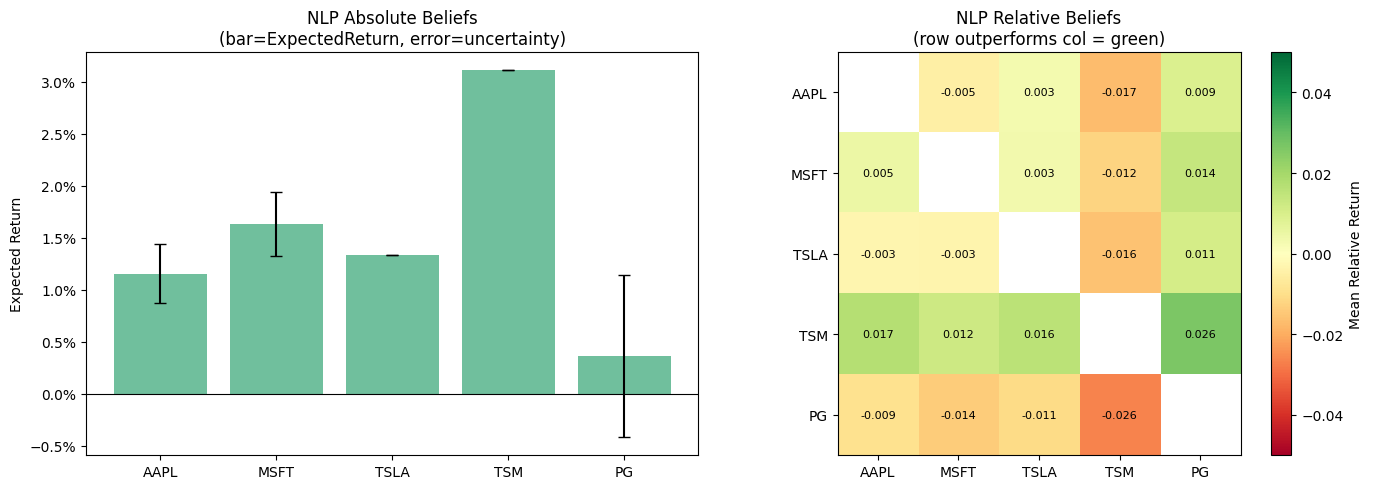

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Absolute beliefs: expected return + confidence ────────────
ax = axes[0]
x       = np.arange(len(TICKERS))
returns = nlp_absolute_beliefs_df.set_index("Ticker").loc[TICKERS, "ExpectedReturn"]
confs   = nlp_absolute_beliefs_df.set_index("Ticker").loc[TICKERS, "Confidence"]
colors  = ["#4caf85" if r >= 0 else "#e05555" for r in returns]

bars = ax.bar(x, returns, color=colors, alpha=0.8)
ax.errorbar(
    x, returns,
    yerr=(1 - confs) * abs(returns).max() * 0.3,
    fmt="none", color="black", capsize=4, linewidth=1.5,
)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("NLP Absolute Beliefs\n(bar=ExpectedReturn, error=uncertainty)")
ax.set_ylabel("Expected Return")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

# ── Relative beliefs heatmap ──────────────────────────────────
ax = axes[1]
n = len(TICKERS)
heat = np.full((n, n), np.nan)

for _, row in nlp_relative_beliefs_df.iterrows():
    i = TICKERS.index(row["Asset_A"])
    j = TICKERS.index(row["Asset_B"])
    heat[i, j] =  row["MeanRelativeReturn"]
    heat[j, i] = -row["MeanRelativeReturn"]

im = ax.imshow(heat, cmap="RdYlGn", vmin=-0.05, vmax=0.05)
fig.colorbar(im, ax=ax, label="Mean Relative Return")
ax.set_xticks(range(n)); ax.set_xticklabels(TICKERS)
ax.set_yticks(range(n)); ax.set_yticklabels(TICKERS)
ax.set_title("NLP Relative Beliefs\n(row outperforms col = green)")

for i in range(n):
    for j in range(n):
        if not np.isnan(heat[i, j]):
            ax.text(j, i, f"{heat[i,j]:.3f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

---
## 14. Export Beliefs for Black-Litterman Layer

Save both DataFrames to CSV so the BL notebook can load them directly.
The schema is identical to the HMM notebook's output, so the BL layer
can consume both with the same code path.

In [ ]:
# BL-ready columns only
BL_ABS_COLS = ["Ticker", "ExpectedReturn", "ProbabilityPositive", "Confidence"]
BL_REL_COLS = ["Asset_A", "Asset_B", "MeanRelativeReturn", "StdRelativeReturn", "ProbabilityOutperform"]

nlp_absolute_beliefs_df[BL_ABS_COLS].to_csv("nlp_absolute_beliefs.csv", index=False)
nlp_relative_beliefs_df[BL_REL_COLS].to_csv("nlp_relative_beliefs.csv", index=False)

print("Exported:")
print("  nlp_absolute_beliefs.csv")
print("  nlp_relative_beliefs.csv")
print()
print("Final NLP Absolute Beliefs (BL schema):")
display(nlp_absolute_beliefs_df[BL_ABS_COLS])
print()
print("Final NLP Relative Beliefs (BL schema):")
display(nlp_relative_beliefs_df[BL_REL_COLS])
print()
print("Strongest NLP Views (sorted):")
display(
    nlp_relative_beliefs_df[BL_REL_COLS]
    .sort_values("MeanRelativeReturn", ascending=False)
)

Exported:
  nlp_absolute_beliefs.csv
  nlp_relative_beliefs.csv

Final NLP Absolute Beliefs (BL schema):


,Ticker,ExpectedReturn,ProbabilityPositive,Confidence
0,AAPL,0.011566,0.725483,0.450966
1,MSFT,0.016346,0.782571,0.565141
2,TSLA,0.013368,0.772339,0.544677
3,TSM,0.031107,0.871070,0.742139
4,PG,0.003634,0.567773,0.135546



Final NLP Relative Beliefs (BL schema):


,Asset_A,Asset_B,MeanRelativeReturn,StdRelativeReturn,ProbabilityOutperform
0,AAPL,MSFT,-0.004737,0.009263,0.402477
1,AAPL,TSLA,0.002885,0.016755,0.510316
2,AAPL,TSM,-0.017089,0.016469,0.243139
3,AAPL,PG,0.009275,0.011103,0.674355
4,MSFT,TSLA,0.003394,0.011266,0.564326
5,MSFT,TSM,-0.012353,0.019555,0.332893
6,MSFT,PG,0.014012,0.014455,0.728071
7,TSLA,TSM,-0.015746,0.021201,0.310162
8,TSLA,PG,0.010618,0.011509,0.702101
9,TSM,PG,0.026364,0.021636,0.846423



Strongest NLP Views (sorted):


,Asset_A,Asset_B,MeanRelativeReturn,StdRelativeReturn,ProbabilityOutperform
9,TSM,PG,0.026364,0.021636,0.846423
6,MSFT,PG,0.014012,0.014455,0.728071
8,TSLA,PG,0.010618,0.011509,0.702101
3,AAPL,PG,0.009275,0.011103,0.674355
4,MSFT,TSLA,0.003394,0.011266,0.564326
1,AAPL,TSLA,0.002885,0.016755,0.510316
0,AAPL,MSFT,-0.004737,0.009263,0.402477
5,MSFT,TSM,-0.012353,0.019555,0.332893
7,TSLA,TSM,-0.015746,0.021201,0.310162
2,AAPL,TSM,-0.017089,0.016469,0.243139


## Hindsight Observations:

TSM and TSLA are at higher outperformance confidence than expected, but likely for different reasons:

**TSM**: sample size problem
- Only 601 mentions, so we're left with very few $TSM / "TSMC" matches spread across 13 months.
- With so few tweets per month, we're getting periods where every month happens to be positive just by chance, so this is not a reliable signal.
- TSM is a B2B semiconductor company; retail Twitter simply doesn't talk about it much.

**TSLA**: genuine bias
- 44,211 mentions is a massive sample, so this isn't noise
- The fine-tuned model is reading Tesla tweets as uniformly positive every single month across a 2-year window that included a ~65% stock price decline in 2022
- This is likely retail investor optimism bias; i.e., Tesla Twitter was a cult following that stayed bullish even as the stock collapsed.

### Overall
NLP sentiment diverges from price returns during the 2022 bear market for high-conviction retail names.

This illustrates why Black-Litterman is likely the right framework. The HMM will likely have picked up the 2022 regime shift and will generate a conflicting bearish view, and BL will reconcile them weighted by confidence.

---
## Summary

| Step | What happened |
|---|---|
| Fine-tuning | `ProsusAI/finbert` adapted to tweet domain on 11,932 labeled examples |
| Evaluation | Fine-tuned vs. base FinBERT compared on accuracy + macro F1 |
| Inference | All Kaggle tweets scored as `P(positive) − P(negative)` ∈ [−1, +1] |
| Aggregation | Scores grouped by ticker × period; volume-weighted mean + std |
| Absolute beliefs | Per-ticker `ExpectedReturn`, `ProbabilityPositive`, `Confidence` |
| Relative beliefs | All pairwise views with `MeanRelativeReturn`, `StdRelativeReturn`, `ProbabilityOutperform` |
